# 01 — Exploratory data analysis (Stage 0)
All logic lives in `src/eda.py`; this notebook only calls it and displays results. It reads the compact parquet
written by `python src/prepare.py` (run that first) and keeps peak RAM under the 5 GB budget.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import pandas as pd, matplotlib.pyplot as plt
from IPython.display import Markdown, display
import eda, plots
from memtrack import peak_rss_gb
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Row counts per source and country
Note that `test_source2.tsv` is **missing** from the provided test folder: test matches can only come from S3 unless the file is supplied.

In [2]:
eda.source_counts()

country       (file missing)  France    India        US     total
split source                                                     
test  S1                   0  259452   809986    663106   1732544
      S2                   0       0        0         0         0
      S3                   0  731615  2405000   1945701   5082316
train S1                   0       0   883188   1323633   2206821
      S2                   0       0  2017799   3016817   5034616
      S3                   0       0  2115547   3170056   5285603
total                      0  991067  8231520  10119313  19341900

## 2. Labels: singletons and match counts
Macro F0.5 averages over all S1 entities, so the singleton share sets how much an empty prediction is worth.

In [3]:
mc = eda.s1_match_counts()
eda.label_summary(mc)

,s1_entities,singleton_share,mean_matches,mean_matches_non_singleton,max_matches,has_S2_and_S3
US,1323633,0.0558,3.4591,3.6636,11,0.8047
India,883188,0.0559,3.4645,3.6696,11,0.8050
all,2206821,0.0558,3.4613,3.6660,11,0.8048


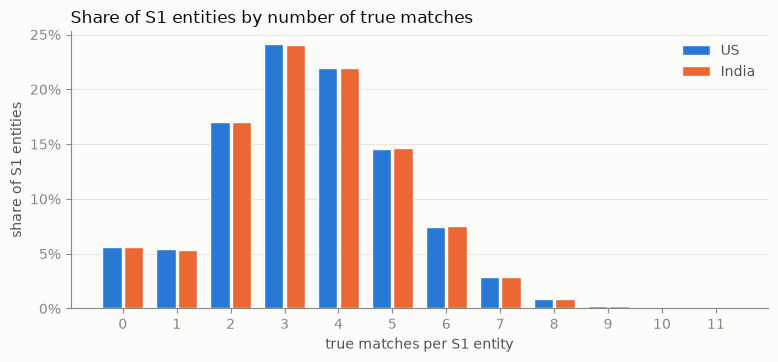

country,US,India
n_matches,,
0,0.0558,0.0559
1,0.0542,0.0537
2,0.1702,0.1698
3,0.2409,0.2400
4,0.2194,0.2193
5,0.1455,0.1464
6,0.0743,0.0753
7,0.0289,0.0291
8,0.0085,0.0085


In [4]:
dist = eda.match_count_distribution(mc).drop(index="total", columns="total")
share = dist / dist.sum()
plots.grouped_bars(share, "Share of S1 entities by number of true matches", "true matches per S1 entity", "share of S1 entities")
plt.show()
share

## 3. Assignment checks
Is every S2/S3 record owned by at most one S1 (a one-to-one constraint we can exploit)? Any cross-country matches?

In [5]:
eda.assignment_checks()

{'true_pairs': 7638365,
 'S2/S3 ids matched to >1 S1': 0,
 'truth ids missing from S2/S3 files': 0,
 'cross-country true pairs': 0,
 'S2 matched share': np.float64(0.7336446314872872),
 'S3 matched share': np.float64(0.7463190103380826)}

In [6]:
del mc

## 4. Noise profile per source
Shares of records showing each noise pattern. Non-ASCII covers every Indic script (Devanagari, Gurmukhi, Gujarati, Bengali, Kannada ...) and French accents.

In [7]:
eda.noise_profile()

rows  empty_addr  upper_addr  name_len  devanagari_name  non_ascii_name  junk_prefix_name  domain_like_name  legal_suffix  landmark_addr  5digit_code  6digit_pin
split source country                                                                                                                                                                      
train S1     US       1323633      0.0000      0.0000   22.4651           0.0000          0.0000            0.0014            0.0000        0.4841         0.0001       0.1082      0.0013
             India     883188      0.0000      0.0000   26.3863           0.0000          0.0000            0.0014            0.0000        0.8352         0.1325       0.0027      0.0000
      S2     India    2017799      0.0287      0.2457   27.4199           0.1335          0.2787            0.1165            0.0271        0.5605         0.1133       0.0107      0.0000
             US       3016817      0.0368      0.9325   23.5543           0.0000          0.0670            0.0259            0.0350        0.4248         0.0001       0.1013      0.0139
      S3     US       3170056      0.0350      0.0000   23.9772           0.0000          0.0680            0.0250            0.0337        0.4203         0.0001       0.1017      0.0133
             India    2115547      0.0307      0.0004   27.0376           0.0747          0.1849            0.0715            0.0290        0.6305         0.0860       0.0100      0.0000
test  S1     US        663106      0.0000      0.0000   22.4633           0.0000          0.0000            0.0014            0.0000        0.4840         0.0001       0.1082      0.0012
             France    259452      0.0000      0.0000   19.4229           0.0000          0.1572            0.0384            0.0000        0.5995         0.0000       0.0039      0.0001
             India     809986      0.0000      0.0000   26.3748           0.0000          0.0000            0.0015            0.0000        0.8351         0.1323       0.0026      0.0000
      S3     India    2405000      0.0246      0.0004   27.8673           0.0753          0.1821            0.0708            0.0236        0.6466         0.0854       0.0096      0.0000
             France    731615      0.0294      0.0000   21.1402           0.0000          0.2394            0.0387            0.0267        0.4532         0.0001       0.0051      0.0002
             US       1945701      0.0284      0.0000   24.6192           0.0000          0.0639            0.0233            0.0277        0.4447         0.0001       0.1041      0.0137

## 5. How similar are true pairs?
A 100k sample of true pairs, compared on the `basic_key` normalised text (rapidfuzz token-set ratio).

In [8]:
sim = eda.true_pair_similarity()
eda.summarise_similarity(sim)

pairs  exact_name  exact_addr  name_tokset_median  name_tokset_below_60  addr_tokset_median  cand_empty_addr  cand_devanagari
country cand_source                                                                                                                               
India   S2           19437      0.1715      0.1160             93.3333                0.2756             99.3631           0.0380           0.1320
        S3           20882      0.1980      0.0416             96.9697                0.1909             93.3333           0.0406           0.0749
US      S2           28829      0.3025      0.1346            100.0000                0.0492             94.9153           0.0473           0.0000
        S3           30852      0.3044      0.0445            100.0000                0.0493             87.3239           0.0461           0.0000

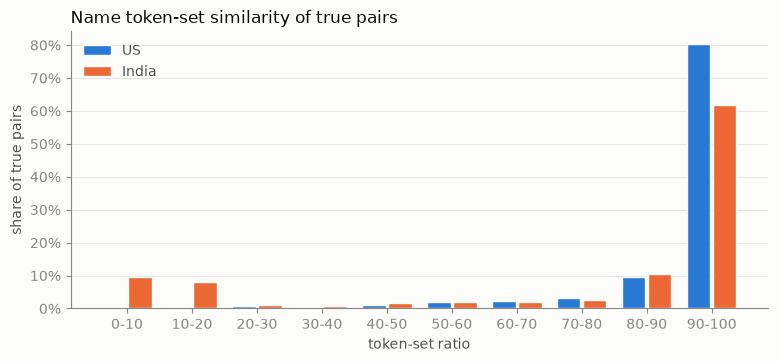

In [9]:
import numpy as np
bins = np.arange(0, 101, 10)
h = pd.DataFrame({c: np.histogram(sim.name_token_set[sim.country == c], bins=bins)[0] for c in ["US", "India"]},
                 index=[f"{b}-{b+10}" for b in bins[:-1]])
plots.grouped_bars(h / h.sum(), "Name token-set similarity of true pairs", "token-set ratio", "share of true pairs")
plt.show()

In [10]:
del sim

## 6. Name frequency
Share of records whose normalised name (within a country) is shared by a group of the given size. Large groups are where
exact-name blocking explodes and where false merges happen, so blocking must cap *candidates per record* rather than drop these names.

In [11]:
nf_train, nf_test = eda.name_frequency("train"), eda.name_frequency("test")
display(nf_train); display(nf_test)

name_h             1      2    3-5   6-10  11-50  51-200   >200
pool  country                                                  
S1    US      0.6418 0.1018 0.0915 0.0320 0.0577  0.0731 0.0021
      India   0.5581 0.0755 0.0813 0.0756 0.2069  0.0026 0.0000
S2+S3 India   0.6231 0.1145 0.0987 0.0612 0.0940  0.0086 0.0001
      US      0.6197 0.1263 0.1110 0.0405 0.0545  0.0365 0.0114

name_h             1      2    3-5   6-10  11-50  51-200   >200
pool  country                                                  
S1    US      0.7087 0.0922 0.0618 0.0182 0.1058  0.0132 0.0000
      France  0.6563 0.0952 0.0890 0.0561 0.0842  0.0184 0.0008
      India   0.5646 0.0746 0.0841 0.0715 0.2038  0.0013 0.0000
S2+S3 India   0.7432 0.0878 0.0727 0.0464 0.0470  0.0029 0.0000
      France  0.6471 0.1327 0.0992 0.0385 0.0558  0.0238 0.0029
      US      0.7666 0.0980 0.0598 0.0247 0.0404  0.0094 0.0010

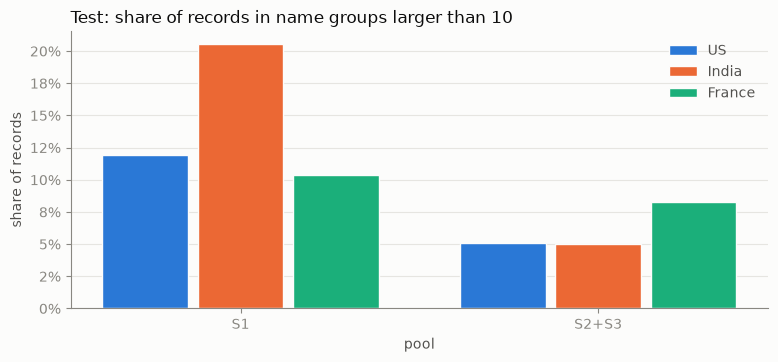

In [12]:
big = nf_test[["11-50", "51-200", ">200"]].sum(axis=1).unstack("pool")
ax = plots.grouped_bars(big.T[["US", "India", "France"]], "Test: share of records in name groups larger than 10",
                        "pool", "share of records")
plt.show()

In [13]:
display(eda.top_names("train")); display(eda.top_names("test"))

,country,name_key,records
0,India,new delhi,266
1,India,india,183
2,India,sc,183
3,India,si,177
4,India,ss,158
5,India,shree,155
6,India,st,144
7,India,mumbai private limited center,137
8,India,services,125
9,India,se,120


,country,name_key,records
0,India,si,166
1,India,sc,158
2,India,india,155
3,India,services,145
4,India,st,142
5,India,new delhi,127
6,India,shree,110
7,India,ss,104
8,India,solutions,98
9,India,sp,93


### Same-name pressure
For each train S1 entity: how many S2/S3 records share its exact normalised name but are **not** its matches.

In [14]:
eda.same_name_pressure()

same_name_false,0,1,2-5,6-20,21-100,>100
country,,,,,,
US,0.6387,0.0703,0.1043,0.0555,0.0849,0.0464
India,0.5814,0.0602,0.1157,0.2253,0.0174,0.0000


## 7. Example matched groups and hard negatives
`hard_negatives` samples 50k S1 entities and caps key groups at 50 (acceptable for exploration only).
`true_share` is the share of joined pairs that are real matches, i.e. the precision of that key used alone.

In [15]:
groups = eda.example_groups()
stats, neg = eda.hard_negatives()
display(stats)
neg.groupby("type").owner.apply(lambda o: o.isna().mean()).rename("share_not_owned_by_any_S1")

,sampled_s1,s1_with_key_group,joined_pairs,true_share,negatives,neg_unowned_distractor,s1_with_>=1_negative
type,,,,,,,
same_name,50000,34360,165869,0.2430,125562,19392,0.3213
same_address,50000,11899,17194,0.8226,3050,171,0.0282
look_alike,50000,34936,49991,0.9642,1788,1547,0.0332


type
look_alike     0.8652
same_address   0.0561
same_name      0.1544
Name: share_not_owned_by_any_S1, dtype: float64

In [16]:
eda.write_examples_md(groups, eda.pick_negative_examples(neg))
display(Markdown((eda.NOTES_DIR / "eda_examples.md").read_text()))

# Stage 0 examples

## 20 matched groups (train)

Sampled with seed 7: 9 US and 9 India entities with matches, plus 2 singletons.

**S1-291055517** [US] Harbor Douglas LLC \| 17115 Castlemaine Lane, Dubuque, IA  — 5 match(es)
- `S2-115876866` Harbor  Douglas LLC \| 17115 CASTLEMAINE LN, DUBUQUE, IA
- `S2-975945593` Harbor Dóuglas (LLC) \| 17115 CASTLEMAINE LN, DUBUQUE, IA
- `S3-92202518` Harbor LLC Douglas \| 17115 Castlemaine Lane, Dubuque, Iowa
- `S3-169416071` Harbor Dóuglas \| 17115 Castlemaine Ln, Dubuque, Iowa
- `S3-340712576` Quoviolyra fka Harbor Douglas LLC \| 17115 Castlemaine Lane, Dubuque, IA

**S1-186056536** [US] QVL United Energetics LLC \| Crossville, 994 Miller Avenue, TN  — 3 match(es)
- `S2-53205799` ... QVL United Energetics L.L.C. \| 994 MILLER AVENUE, CROSSVILLE, TN
- `S2-743959875` QVL United \| *(empty)*
- `S3-920999539` QVL United Energetics-LLC \| 994 Miller Avenue, Crossville, Tennessee

**S1-371583017** [US] Heart Association LP \| 3908 Uranus Avenue, Vandenberg Village, CA  — 4 match(es)
- `S2-735301870` Heart Association LP Board \| 3908-3910 URANUS AVE, VANDENBERG VILLAGE, CA
- `S3-636107916` Heart [Association-LP] \| California, 3908 Uranus Avenue, Vandenberg Village
- `S3-124182217` héartassociation.com \| California, 3908 Uranus Ave, Vandenberg Village
- `S3-996055745` Vantageonyx Formerly Heart Association LP \| 3908 Uranus Avenue, Vandenberg Village, CA

**S1-565371362** [US] Crystal Electronics Union LLC \| 7166 Coffeeville Cove, Memphis, TN  — 3 match(es)
- `S2-523338295` CRYSTAL ELECTRONICS-UNION \| 716 COFFEEVILLE COVE, MEMPHIS, TN
- `S2-790084890` Crystal Electronics Union  LLC \| PO BOX 9820, MEMPHIS, TN, 716 COFFEEVILLE CV
- `S3-614437057` Crystal Union LLC Service \| 7166-7170 Coffeeville Cv, Memphis, Tennessee

**S1-123147361** [US] Jimenez Advisors \| 226 Chestnut Bluff Road, Friendship, TN  — 4 match(es)
- `S2-548024814` Jimenez Advisors \| 226 CHESTNUT BLUFF RD, FRIENDSHIP, TN
- `S3-396324330` Jimenez (Advisors) \| 226 Chestnut Bluff Rd, Friendship CITY, Tennessee
- `S3-134829687` Jimenez Advisors \| 226 Chestnut Bluff Rd, Friendship CITY, Tennessee
- `S3-928733919` jimenez advisors \| 226 Chestnut Bluff Rd, Friendship CITY, Tennessee

**S1-31524483** [US] Delta World LLC \| 216 Hayes Street, Bozeman, MT  — 4 match(es)
- `S2-208568687` Delta World \| 216 HAYES SAINT, BOZEMAN, MT
- `S3-52069812` Delta World \| 216 Hayes Street, Bozeman, Montana
- `S3-92673271` Delta World \| 216 Hayes Saint, Bozeman, Montana
- `S3-580159064` Delta World-L.L.C. \| 216 Hayes St, Bozeman, Montana

**S1-154301123** [US] Main Street Pilates \| 565 Genesee Street, Waukegan, IL, Unit APARTMENT 203  — 4 match(es)
- `S2-563480347` MAIN STREET PILATES \| 565 GENESEE ST, WAUKEGAN, IL
- `S2-284490990` Main Street Pilates Enterprises \| *(empty)*
- `S3-590785311` Main Street Pi1ates Services \| *(empty)*
- `S3-411927599` >> Main Stréet Pilates \| 56 Genesee Saint, Unit Apartment 203, Waukkegan, Illinois

**S1-140058579** [US] Peak Municipals LLC \| 1504 73rd Street, Minot, ND  — 1 match(es)
- `S3-510661919` Peak Municipals \| 73rd Street, Mniot, North Dakota

**S1-446831533** [US] Campbell Vaneck Inc \| 2112 Lucille Street, City Of Appleton, WI  — 3 match(es)
- `S2-546988681` CAMPBELL VENCK INC \| LUCILLE ST, CITY OF APPLETON, WI
- `S2-749779369` Tavoquovantage \| 2112 LUCILLE ST, CITY OF APPLETON, WI
- `S3-211883520` CAMPBELL CAMPBELL VANECK INC \| Wisconsin, City Of Appleton, 2112 Lucille St

**S1-533820389** [India] East Investments Private Limited \| 14333/5-11, New Moti Bagh Colony, Patiala, Punjab  — 4 match(es)
- `S2-611869619` ਈਸਟ ਇਨਵੈਸਟਮੈਂਟਸ ਪ੍ਰਾਈਵੇਟ ਲਿਮਟਿਡ \| PLOT 841 14333/5-11, NEW MOTI BAGH COLONY, PATIALA, Punjab
- `S2-723537333` ਈਸਟ ਇਨਵੈਸਟਮੈਂਟਸ ਪ੍ਰਾਈਵੇਟ ਲਿਮਟਿਡ \| PATIALA, NEW MOTI BAGH COLONY, PATIALA, PLOT 841 14333/5-11, Punjab
- `S2-596256121` East Investments Prívate Límited \| ਪੰਜਾਬ, PLOT 841 14333/5-11, NEW MOTI BAGH COLONY, PATIALA
- `S3-450121782` East Private Limited Sérvices \| 14333/5-11, New Moti Bagh Colony, Patiala, PB

**S1-990843835** [India] My Producer Private Limited \| 6, Om Sai Nagar, Bamroli Road, Pandesara, Surat City, Surat, Gujarat  — 3 match(es)
- `S2-929453933` માય પ્રોડ્યુસર પ્રાઇવેટ લિમિટેડ \| 006, OM SAI NAGAR, BAMROLI ROAD, PANDESARA, SURAT CITY, SURAT, Gujarat
- `S2-619133553` MY PRIVATE PRODUCER LIMITED \| 006, OM SAI NAGAR, BAMROLI ROAD, PANDESARA, SURAT CITY, SURAT, Gujarat
- `S3-550781632` માય પ્રોડ્યુસર પ્રાઇવેટ લિમિટેડ \| GJ, Surat, 6

**S1-259252641** [India] Shree Information Private Limited \| 4Th Floor, No 97, Sanjayanagar Main Road N N Complex, Rmv Ii Stage, Geddalahalli, Bangalore, Karnataka  — 4 match(es)
- `S2-366503822` Shree Information Limited Center \| 4TH FLOOR, NO 97, SANJAYANAGAR MAIN ROAD N N COMPLEX, RMV II STAGE, GEDDALAHALLI, BANGALORE, ಕರ್ನಾಟಕ
- `S2-922094496` Shree Limited Private  Information \| Karnataka, #4TH FLOOR, NO 97, SANJAYANAGAR MAIN ROAD N N COMPLEX, RMV II STAGE, GEDDALAHALLI, BANGALORE
- `S3-342803668` Shree Information Private Ltd \| Floor, Bengaluru Hq Region, KA
- `S3-295215090` Gildvio \| 4Th Floor, No 97, Sanjayanagar Main Road N N Complex, Rmv Ii Stage, Geddalahalli, Bangalore, Karnataka

**S1-258297619** [India] Yummy Consultancy \| Prashil Park, Block No. 92, Near Saurashtra University, Kalawad Road, Rajkot, Gujarat  — 7 match(es)
- `S2-782645039` Yummy Consultancy Corporation \| PRASHIL PARK, BLOCK NO. 092, NEAR SAURASHTRA UNIVERSITY, KALAWAD ROAD, RAJKOT, Gujarat
- `S2-112800321` Yummy Sérvice \| PRASHIL PARK, BLOCK NO. 092, NEAR SAURASHTRA UNIVERSITY, KALAWAD ROAD, RMJKOT, Gujarat
- `S3-90304590` Yummy-Cosnlutancy \| Prashil Park, Rajkot, ગુજરાત
- `S3-579220794` Yummy Consultancy Limited \| Prashil Park, Block No. 92, Near Saurashtra University, Kalawad Road, Rajkot, GJ
- `S3-337000088` Yummy Services \| Prashil Park, Block No. 92, Near Saurashtra University, Kalawad Road, Rajkot, GJ
- `S3-299672527` Yummy Center Center \| ગુજરાત, Prashil Park, Rajkot
- `S3-282736811` Yummy-Consultancy \| Prashil Park, Rajkot, GJ

**S1-756556013** [India] Great Food Private Limited \| 4, Synagogue Street 4Th Floor - Room No-404, Kolkata, Howrah, West Bengal  — 3 match(es)
- `S2-697480613` গ্রেট ফুড প্রাইভেট লিমিটেড \| 4, SYNAGOGUE STREET 4TH FLOOR - ROOM NO-404, KOLKATA, HOWRAH, West Bengal
- `S3-192579617` M/s Great Food Limited Private \| #4, Synagogue Street 4Th Floor - Room No-404, Kolkata, Howrah, WB
- `S3-757134563` foodprivategreat.com \| #4, Howrah, Kolkata, WB

**S1-68493521** [India] Jkm & Co Limited \| 303, Marathon Chambers, Near Paanch Raasta P.K. Road, Mulund(West), Mumbai, Mumbai City, Maharashtra  — 4 match(es)
- `S2-13121872` Jkm & Co Ltd \| A-303, MARATHON CHAMBERS, NEAR PAANCH RAASTA P.K. ROAD, MULUND(WEST), MUMBAI, Maharashtra
- `S2-66239566` Jkm Co Límited-Center \| A-303, MARATHON CHAMBERS, NEAR PAANCH RAASTA P.K. ROAD, MULUND(WEST), MUMBAI, Maharashtra
- `S3-199258964` Jkm Co Limited Partners \| 303, Mumbai, Mumbai City, महाराष्ट्र
- `S3-767713572` Jkm Co Limited Services \| 303, Mumbai, Mumbai City, MH

**S1-179900791** [India] Tele & Sons Pvt. Ltd. \| Flat # 12, 2Nd Flr, Ratna Villa Apartments, No.11/1, 1St Cross, S.R.Layout, Obamma Line, Muru, Geshpalya, Bangalore, Karnataka  — 3 match(es)
- `S2-45848568` Dr tsons.com \| FLAT # 12, 2ND FLR, RATNA VILLA APARTMENTS, NO.11/1, 1ST CROSS, S.R.LAYOUT, OBAMMA LINE, MURU, GESHPALYA, BANGALORE, BENGALURU, Karnataka
- `S2-324902863` Tele & Sons Pvt. \| FLAT # 12, 2ND FLR, RATNA VILLA APARTMENTS, NO.11/1, 1ST CROSS, S.R.LAYOUT, OBAMMA LINE, MURU, GESHPALYA, BANGALORE, Karnataka
- `S3-279994164` Tele + Sons Pvt.  Ltd \| Flat # 9-12, 2Nd Flr, Ratna Villa Apartments, No.11/1, 1St Cross, S.r.layout, Obamma Line, Muru, Geshpalya, Bangalore, ಕರ್ನಾಟಕ

**S1-121146726** [India] Universal Industries Private Limited \| Teghoria P O Hatiara Rajarhat, Kolkata, Calcutta, West Bengal  — 2 match(es)
- `S3-507623806` universalindustries.com \| Calcutta, Teghoria P O Hatiara Rajarhat, WB, Kolkata
- `S3-244900717` Novitavonovi doing business as Universal Industries Private Limited \| Teghoria P O Hatiara Rajarhat, Kolkata, Calcutta, West Bengal

**S1-636256488** [India] Shell Audio Private Limited \| Mustaque Ahmad, Bank Gali, Muradpur, Patna, Bihar  — 1 match(es)
- `S3-133642294` Shell Audio Private \| Mustaque Ahmad, BR, Patna

**S1-177568041** [US] Hernandez Mitsubishi LP \| 970 Saturn Lane, Bremerton, WA  — 0 match(es)
- *(singleton: no matches)*

**S1-903822211** [US] Big Ice Cream \| 17659 Rosland Road, La Pine, OR  — 0 match(es)
- *(singleton: no matches)*

## 20 hard negatives (train)

Non-matching S2/S3 records that collide with a sampled S1 entity on name or address. `owner` is the S1 entity the record really belongs to (blank = matches no S1).

| type | S1 entity | S1 name \| address | negative | negative name \| address | real owner name \| address |
|---|---|---|---|---|---|
| same_name | S1-811897601 | Federal Foundation Inc \| 5903 Whisper Creek Drive, Georgetown, TX | S3-503072519 | Federal Foundation Inc \| 804 Lake Carolyn Parkway, # 3013, Irving, Texas | *(none — distractor)* |
| same_name | S1-202426477 | Shiv Projects Private Limited \| 387/1, Plot No 49, Kamakshi Layout Saibanagar, Nagpur, Maharashtra | S3-160725248 | SHIV Projects Private Limited \| Hno-4 Mohalla Itauva Khushhal Bard -9 Baheri Near Shiv Mandir, Bahaeri, Bareilly, UP | Shiv Projects Private Limited \| Bareilly, Uttar Pradesh, Hno-4 Mohalla Itauva Khushhal Bard -9 Baheri Near Shiv Mandir, Bahaeri |
| same_name | S1-781263332 | Raj Infrastructure Private Limited \| Thane, Yash Arcade 1St Floor Near Aims Hospital Milap Nagar, Dombivli, Maharashtra | S3-733593275 | Raj Infrastructure Private [Limited] \| C/o Neha Mithil Pitre Omkarniwas Sanmitr Nagar Near Newenglish School Middle Lane, Ratnagiri, MH | Raj Infrastructure Private Limited \| C/O Neha Mithil Pitre Omkarniwas Sanmitr Nagar Near Newenglish School Middle Lane, Devrukh, Tq Sangmeshwar, Ratnagiri, Maharashtra |
| same_name | S1-11385905 | Green Agro Private Limited \| 91, Pr3534, Rohtak, Haryana | S3-518860465 | green agro private limited \| A-1201, Mumbai (SUBURBAN), Mumbai, MH | Green Agro Private Limited \| 1201, Vicinia Tower B Plot, No Cts 15A 15C 15D 15E, Mumbai, Maharashtra |
| same_name | S1-898878765 | Silver Software Private Limited \| 927/302, Sanas Memories, Third Floor F.C. Road, Shivajinagar, Pune, Maharashtra | S2-687714365 | Silver  Software Private Limited \| C/O HARI SHANKAR, MAJHAWA BAT PASSFZD, FAIZABAD, Uttar Pradesh | Silver Software Private Limited \| C/O Hari Shankar, Majhawa Bat Passfzd, Faizabad, Uttar Pradesh |
| same_name | S1-234959964 | Big Investments Private Limited \| House No. 3/024, Vipul Khand-3, Lucknow, Uttar Pradesh | S2-592307835 | Big Investments Private Limited \| 2259 , BUILDING NO.46, SU-PRABHTA CHS M.H.B. COLONY, GANDHI NAGAR, BANDRA(E), MUMBAI, Maharashtra | *(none — distractor)* |
| same_name | S1-200260031 | Gedyne \| 3908 Koehler Street, Houston, TX | S2-760699917 | Gedyne \| 0022632 OBSERVATION DRIVE, CLARKSBURG, MD | Gedyne \| 22632 Observation Drive, Clarksburg, MD |
| same_address | S1-665599102 | Dermatology Group \| 8 Mountain Avenue, Somerville, MA | S2-330295188 | Internal Medicine Corp Center \| 8 MOUNTAIN AVENUE, SOMERVILLE, MA | Internal Medicine Physicians Corp \| 8 Mountain Avenue, Somerville, MA |
| same_address | S1-89857091 | Frontier Reliable Keystone Inc \| 2024 Guntersville Bend, Leander, TX | S2-625253883 | Dental Creative \| 2024 GUNTERSVILLE BEND, LEANDER, TX | Dental Creative Physicians \| 2024 Guntersville Bend, Leander, TX |
| same_address | S1-605729169 | Martinez Reit LLC \| 220 Elm Avenue, Holly Springs, NC | S2-215383647 | Jessica's Capital Foods \| 220 ELM AVENUE, HOLLY SPRINGS, NC | Jessica's Capital Foods Inc \| 220 Elm Avenue, Holly Springs, NC |
| same_address | S1-980032302 | Preferred Tinto \| 111 Cr 52, Rosharon, TX | S3-78238457 | Evoyuma D.B.A. Timber \| 111 Cr 52, Rosharon, TX | Timber \| 111 Cr 52, Rosharon, TX |
| same_address | S1-266184054 | Montiel & Bates L.L.C. \| 194 Kierra Place, Mountain Home, AR | S2-867648526 | Garcia, Nicola, \| 194. KIERRA PLACE, MOUNTAIN HOME, AR | Garcia, Nicola, M.D. \| 194 Kierra Place, Mountain Home, AR |
| same_address | S1-421270396 | Dental Fresh Center LLC \| 143 A Hartley Drive, High Point, NC | S3-251800859 | Calokorflux aka Diaz and Washington Inc. \| 143 A Hartley Drive, High Point, NC | Diaz and Washington Inc. \| 143 A Hartley Drive, High Point, NC |
| look_alike | S1-335958482 | Continental Strategic Network Co \| 7083 50, Shoals, IN | S3-916041976 | continental strategic network holdings \| 7104 50, Shoals, Indiana | *(none — distractor)* |
| look_alike | S1-113262242 | Clean Payment Alliance Inc \| 284 296, Smiths Station, AL | S3-281764109 | The Clean Payment Alliance Group \| 289 296, Smiths Station, Alabama | *(none — distractor)* |
| look_alike | S1-356335164 | Rhombus Traders Ltd \| Flat No-7D-80-Sfs G-8 Area Rajouri Garden, New Delhi, South West Delhi, Delhi | S2-986278340 | RHOMBUS  TRADERS INFRATECH \| FLAT NO-7D-80-SFS G-10 AREA RAJOURI GARDEN, NEW DELHI, Delhi | *(none — distractor)* |
| look_alike | S1-923565088 | Srushti Traders Private Limited \| D-192 To D-195, Midc Shendra Five Star Industrial, Aurangabad, Maharashtra | S2-720486104 | Srushti Traders Overseas Private Ltd \| D-192. TO D-216, MIDC SHENDRA FIVE STAR INDUSTRIAL, AURANGABAD, Maharashtra | *(none — distractor)* |
| look_alike | S1-325901525 | Mosoft Iheartmedia LLC \| 3531 8 Mile Road, Village Of Raymond, WI | S2-393945936 | Mosoft Iheartmedia  Metro \| 3544 8 MILE ROAD, CAEDONIA, WI | *(none — distractor)* |
| look_alike | S1-182496613 | Standard Automation Networks \| 1440 20th Street, Unit Unit 10, West Des Moines, IA | S3-380370001 | Standard Automation Networks Northside \| 01443 20nd St, # Unit 10, West Des Moines, Iowa | *(none — distractor)* |
| look_alike | S1-517358468 | Vision Engineering Private Limited \| Ahmedabad, Gujarat, Ahmadabad City, Opp Vaikunth Bunglows, New India Colony Road, Nicol, 4Th F 16 Raspan Arcade | S2-194885691 | Vision Engineering (L.L.P.) \| 11TH F 16 RASPAN ARCADE, OPP VAIKUNTH BUNGLOWS, NEW INDIA COLONY ROAD, NICOL, AHMADABAD CITY, ગુજરાત | *(none — distractor)* |


## 8. Candidate budget (Stage 3b)
A smaller candidate set per S1 ranks higher, and the target is about 2–5 candidates at ≥ 95% pair completeness. With about 3.46 true
matches per S1, even a perfect pruner needs at least 0.95 × 3.46 ≈ 3.29 candidates on average. The reduction ratio is already about 0.999999
at 4 candidates per S1, so it cannot separate operating points.

In [17]:
eda.candidate_budget()

S1    S2+S3      all_pairs   true_pairs  mean_true_per_S1  min_avg_cands_for_95pct  reduction_ratio_at_4_per_S1
split country                                                                                                                      
train US       1323633  6186873  8189149269609 4578522.0000            3.4591                   3.2861                       1.0000
      India     883188  4133346  3650521587048 3059843.0000            3.4645                   3.2913                       1.0000
test  India     809986  2405000  1948016330000          NaN               NaN                      NaN                       1.0000
      US        663106  1945701  1290206007306          NaN               NaN                      NaN                       1.0000
      France    259452   731615   189818974980          NaN               NaN                      NaN                       1.0000

Best pair completeness for a fixed per-S1 cap k, assuming a **perfect** ranker. A fixed cap needs k ≥ 5 to reach 95%, so the pruner uses an adaptive cutoff instead.

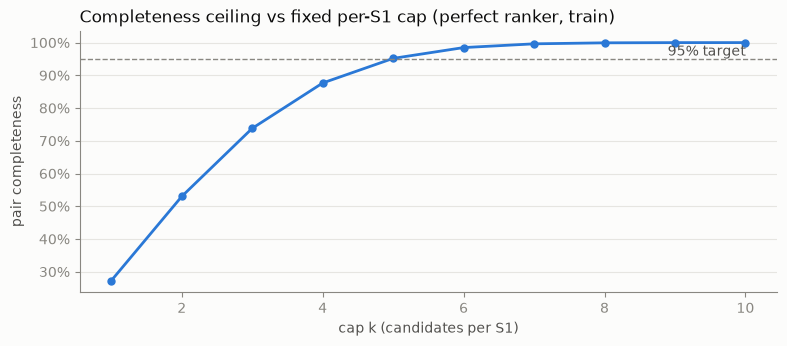

,completeness_ceiling,avg_cands_if_oracle
k,,
1,0.2728,0.9442
2,0.5300,1.8343
3,0.7380,2.5544
4,0.8766,3.0340
5,0.9517,3.2942
6,0.9848,3.4086
7,0.9962,3.4482
8,0.9993,3.4588
9,0.9999,3.4610


In [18]:
orc = eda.oracle_topk_completeness()
ax = plt.subplots(figsize=(9, 3.4), facecolor=plots.SURFACE)[1]
ax.plot(orc.index, orc.completeness_ceiling, color=plots.SERIES[0], linewidth=2, marker="o", markersize=5)
ax.axhline(0.95, color=plots.MUTED, linewidth=1, linestyle="--")
ax.text(orc.index.max(), 0.95, "  95% target", va="bottom", ha="right", color=plots.INK2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plots.style(ax, "Completeness ceiling vs fixed per-S1 cap (perfect ranker, train)", "cap k (candidates per S1)", "pair completeness")
plt.show()
orc

## 9. Resources

In [19]:
print(f"peak RSS of this kernel: {peak_rss_gb():.2f} GB")

peak RSS of this kernel: 4.40 GB
